In [ ]:
# @title Import Libraries
! pip install numpyro

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
import jax.numpy as jnp
from jax import random
import arviz as az
from typing import Dict, Optional
from jax.typing import ArrayLike
import seaborn as sns
from numpyro.diagnostics import hpdi
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.1/356.1 kB 7.1 MB/s eta 0:00:00


In [ ]:
df = pd.read_parquet("CustomerData.parquet")
df = df[df["Dollars Spent 2021"].between(55,105)].reset_index(drop=True)
df['treatment'] = (df['Dollars Spent 2021'] > 80).astype(int)
df['interaction'] = df['Dollars Spent 2021'] * df['treatment']
df.head()

,Customer ID,Dollars Spent 2021,Dollars Spent 2022,treatment,interaction
0,8f4657d9-a63a-4dfa-b429-d31cb3633d79,97.266983,112.984993,1,97.266983
1,837fcbca-d9eb-4092-a488-410c267b2ee5,74.962494,84.195442,0,0.000000
2,cd699e40-babf-4d5b-bdd0-39da9a62f8e6,97.165199,104.639359,1,97.165199
3,020c18bd-47ed-487f-9164-7d2f5d67ac7a,101.865532,134.245544,1,101.865532
4,d2ea4522-2992-4e71-9aad-4755e8245f70,79.051300,100.077911,0,0.000000


In [ ]:
def my_model(x, y=None):
  intercept = numpyro.sample("intercept", dist.Uniform(0,200))
  xCoef = numpyro.sample("xCoef", dist.Normal(1))
  tCoef = numpyro.sample("tCoef", dist.Uniform(-100,100))
  interxn = numpyro.sample("interxn", dist.Uniform(-1,1))
  sigma = numpyro.sample("sigma", dist.Uniform(0,100))
  mu = numpyro.deterministic('mu', intercept + xCoef*x[:,0] + tCoef*x[:,1] + interxn*x[:,0]*x[:,1])
  numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)

X = df["Dollars Spent 2021"].values
y = df["Dollars Spent 2022"].values
t = df["treatment"].values
X = jnp.column_stack((X, t))

In [ ]:
mcmc = MCMC(sampler=NUTS(my_model),
  num_warmup=1000,
  num_samples=9000,
  num_chains=4)

mcmc.run(rng_key=random.PRNGKey(seed=123), x=X, y=y)
mcmc.print_summary(prob=0.95)

<ipython-input-4-20f9fa26828b>:1: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(sampler=NUTS(my_model),
sample: 100%|██████████| 10000/10000 [01:04<00:00, 156.00it/s, 107 steps of size 3.63e-02. acc. prob=0.94]



                 mean       std    median      2.5%     97.5%     n_eff     r_hat
  intercept     11.94      1.59     11.92      8.79     15.03  12225.45      1.00
    interxn     -0.21      0.04     -0.21     -0.30     -0.13  11330.85      1.00
      sigma      9.98      0.10      9.97      9.79     10.17  17848.32      1.00
      tCoef     22.94      3.68     22.92     15.83     30.23  11871.40      1.00
      xCoef      1.07      0.02      1.07      1.02      1.12  12229.41      1.00

Number of divergences: 0


array([[<Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'intercept'}>],
       [<Axes: title={'center': 'xCoef'}>,
        <Axes: title={'center': 'xCoef'}>],
       [<Axes: title={'center': 'tCoef'}>,
        <Axes: title={'center': 'tCoef'}>],
       [<Axes: title={'center': 'interxn'}>,
        <Axes: title={'center': 'interxn'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

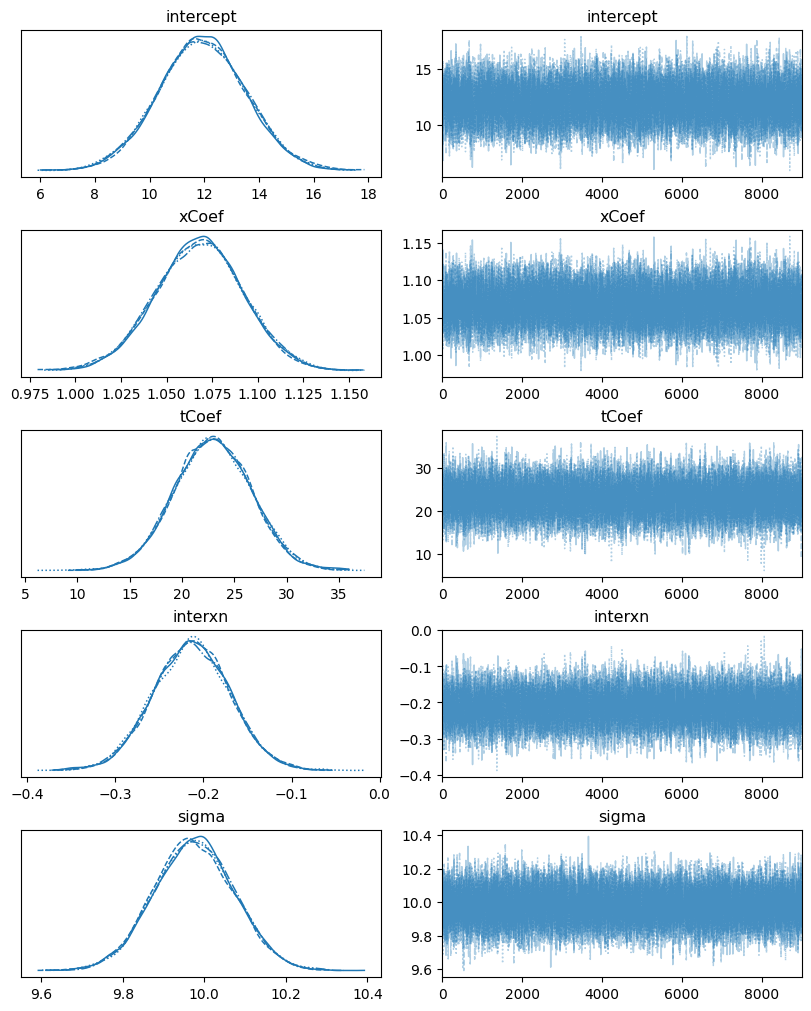

In [ ]:
az.plot_trace(mcmc, var_names=['intercept', 'xCoef', 'tCoef', 'interxn', 'sigma'], figsize=(8,10),
              backend_kwargs={'constrained_layout': True})

In [ ]:
from numpyro.infer import MCMC, NUTS, Predictive
predictive = Predictive(
  model=my_model,
  num_samples=10000
)
prior_samples = predictive(rng_key=random.PRNGKey(seed=123),x=X,y=y)
posterior_samples = mcmc.get_samples()

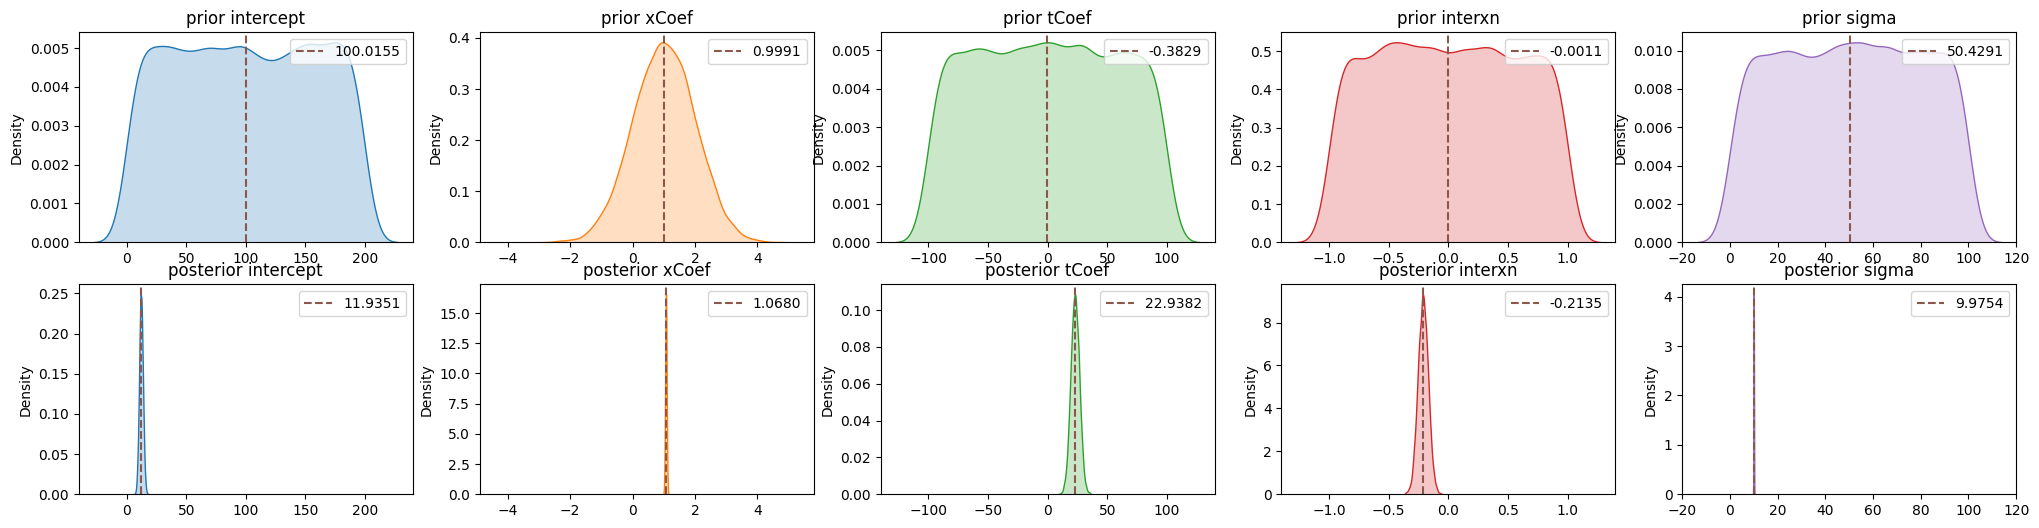

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def kde_plot(x, ax, color, title):
    mean = x.mean()
    sns.kdeplot(x=x, ax=ax, fill=True, color=color)
    ax.axvline(
        x=mean,
        label=f"{mean:.4f}",
        color="C5",
        ls="--",
    )
    ax.set_title(f"{title}")
    ax.legend()


param_keys = ['intercept', 'xCoef', 'tCoef', 'interxn', 'sigma']
n_cols = len(param_keys)
_, axs = plt.subplots(2, n_cols, figsize=(5 * n_cols, 6))
for i, key in enumerate(param_keys):
        kde_plot(
            x=prior_samples[key],
            title=f"prior {key}",
            ax=axs[0, i],
            color=f"C{i}",
  )
        kde_plot(
            x=posterior_samples[key],
            title=f"posterior {key}",
            ax=axs[1, i],
            color=f"C{i}",
  )
        axs[1, i].sharex(axs[0, i])


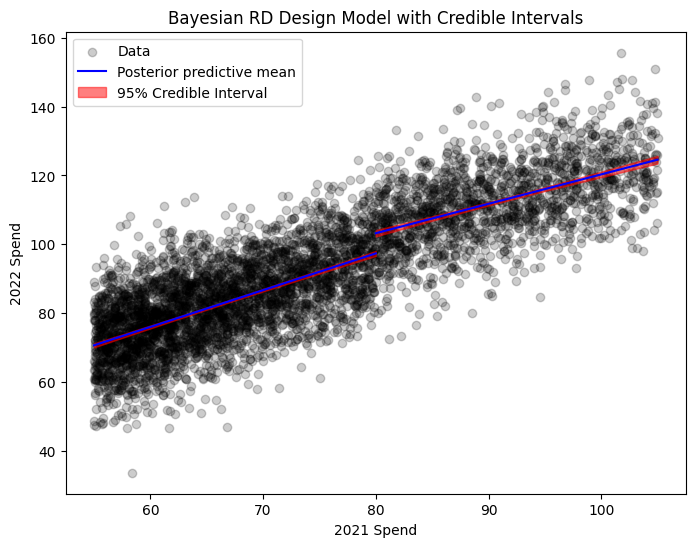

In [ ]:
# Extract posterior samples for beta coefficients and sigma
intercept_samples = posterior_samples['intercept']
xCoef_samples = posterior_samples['xCoef']
tCoef_samples = posterior_samples['tCoef']
interxn_samples = posterior_samples['interxn']
sigma_samples = posterior_samples['sigma']

# Compute posterior predictive distribution for the regression line
X1_plot_0 = jnp.linspace(55, 80, 200)
X1_plot_1 = jnp.linspace(80, 105, 200)
X2_plot_0 = 0
X2_plot_1 = 1
# X2_plot = jnp.linspace(0, 1, 1)
# X1_grid, X2_grid = jnp.meshgrid(X1_plot, X2_plot)
# X1_flat = X1_grid.flatten()
# X2_flat = X2_grid.flatten()

mu_pred_samples_0 = []
mu_pred_samples_1 = []

# For each X1 value, compute the predicted values from the posterior samples
for x1_val in X1_plot_0:
    # Compute predictions for each posterior sample
    mu_samples = intercept_samples + xCoef_samples * x1_val + tCoef_samples * X2_plot_0 + interxn_samples * x1_val * X2_plot_0
    mu_pred_samples_0.append(mu_samples)

for x1_val in X1_plot_1:
    # Compute predictions for each posterior sample
    mu_samples = intercept_samples + xCoef_samples * x1_val + tCoef_samples * X2_plot_1 + interxn_samples * x1_val * X2_plot_1
    mu_pred_samples_1.append(mu_samples)

# Convert list of predictions into a numpy array (shape: [num_samples, num_X1_points])
mu_pred_samples_0 = jnp.array(mu_pred_samples_0)
mu_pred_samples_1 = jnp.array(mu_pred_samples_1)

# Compute the 2.5th and 97.5th percentiles for the credible interval at each X1 value
lower_0 = jnp.percentile(mu_pred_samples_0, 2.5, axis=1)
upper_0 = jnp.percentile(mu_pred_samples_0, 97.5, axis=1)
lower_1 = jnp.percentile(mu_pred_samples_1, 2.5, axis=1)
upper_1 = jnp.percentile(mu_pred_samples_1, 97.5, axis=1)
# lower_0 = 8.79 + 1.02 * X1_plot_0 + 15.83 * X2_plot_0 - 0.3 * X1_plot_0 * X2_plot_0
# upper_0 = 15.03 + 1.12 * X1_plot_0 + 30.23 * X2_plot_0 - 0.13 * X1_plot_0 * X2_plot_0
# lower_1 = 8.79 + 1.02 * X1_plot_1 + 15.83 * X2_plot_1 - 0.3 * X1_plot_1 * X2_plot_1
# upper_1 = 15.03 + 1.12 * X1_plot_1 + 30.23 * X2_plot_1 - 0.13 * X1_plot_1 * X2_plot_1

# Predictive mean
# mu_pred = intercept_samples.mean() + xCoef_samples.mean() * X1_plot + tCoef_samples.mean() * X2_plot + interxn_samples.mean() * X1_plot * X2_plot
mu_pred_0 = mu_pred_samples_0.mean(axis=1)
mu_pred_1 = mu_pred_samples_1.mean(axis=1)

# # Credible intervals
# lower = jnp.percentile(mu_pred, 2.5)
# upper = jnp.percentile(mu_pred, 97.5)

# Plot the data and the credible intervals
plt.figure(figsize=(8, 6))

# Plot data points
plt.scatter(df["Dollars Spent 2021"], df["Dollars Spent 2022"], color='black', label='Data', alpha=0.2)

# Plot the regression line with credible intervals
plt.plot(X1_plot_0, mu_pred_0, color='blue', label="Posterior predictive mean")
plt.plot(X1_plot_1, mu_pred_1, color='blue')
plt.fill_between(X1_plot_0, lower_0, upper_0, color='red', alpha=0.5, label="95% Credible Interval")
plt.fill_between(X1_plot_1, lower_1, upper_1, color='red', alpha=0.5)

# Add labels and title
plt.xlabel("2021 Spend")
plt.ylabel("2022 Spend")
plt.title("Bayesian RD Design Model with Credible Intervals")

plt.legend()
plt.show()


<Axes: ylabel='Count'>

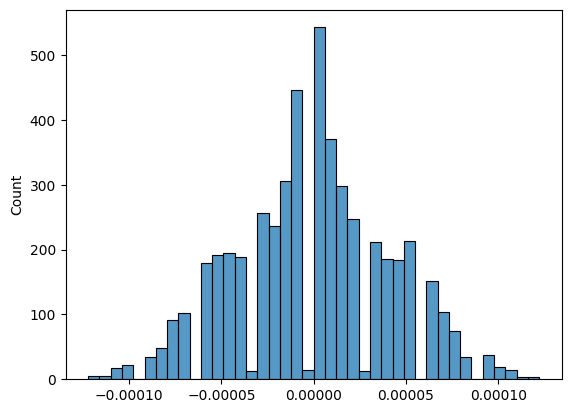

In [ ]:
posterior_samples = mcmc.get_samples()
predictive = Predictive(my_model, posterior_samples)
residuals = y - predictive(rng_key=random.PRNGKey(seed=123), x=X, y=y)["obs"].mean(axis=0)
sns.histplot(residuals)

In [ ]:
post_samps = mcmc.get_samples()
intercept = post_samps["intercept"].mean(axis=0)
xCoef = post_samps["xCoef"].mean(axis=0)
tCoef = post_samps["tCoef"].mean(axis=0)
interxn = post_samps["interxn"].mean(axis=0)

post_preds = []

for i in range(df.shape[0]):
  pred = intercept + xCoef * df.loc[i,"Dollars Spent 2021"] + tCoef * df.loc[i,"treatment"] + interxn * df.loc[i,"interaction"]
  post_preds.append(pred)


<Axes: xlabel='Dollars Spent 2022', ylabel='Count'>

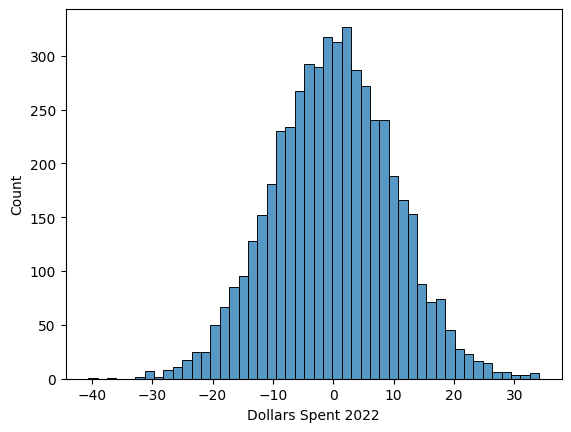

In [ ]:
bay_resids = df["Dollars Spent 2022"] - post_preds
sns.histplot(bay_resids)

In [ ]:
other_model = smf.ols('Q("Dollars Spent 2022") ~ Q("Dollars Spent 2021") + treatment + interaction', data=df).fit()
other_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     Q("Dollars Spent 2022")   R-squared:                       0.712
Model:                                 OLS   Adj. R-squared:                  0.711
Method:                      Least Squares   F-statistic:                     4156.
Date:                     Tue, 03 Dec 2024   Prob (F-statistic):               0.00
Time:                             01:21:52   Log-Likelihood:                -18800.
No. Observations:                     5056   AIC:                         3.761e+04
Df Residuals:                         5052   BIC:                         3.763e+04
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  11.9141      1.574      7.568      0.000       8.828      15.000
Q("Dollars Spent 2021")     1.0683      0.024     44.976      0.000       1.022       1.115
treatment                  23.0084      3.648      6.308      0.000      15.858      30.159
interaction                -0.2144      0.043     -4.965      0.000      -0.299      -0.130
==============================================================================
Omnibus:                        1.110   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.574   Jarque-Bera (JB):                1.067
Skew:                          -0.011   Prob(JB):                        0.587
Kurtosis:                       3.068   Cond. No.                     2.22e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.22e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
jnp.sqrt(other_model.mse_resid)

Array(9.9730215, dtype=float32)